In [6]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from core.training import train_tise
from tise1d.tise1d import Loss_PDE, Loss_Orthogonality, PotentialHarmonicOscillator, ansatzfactor_HO_sym
from utils.utils import generate_input_data
from param_search.A_train_ground_state import load_ground_state_pinn
from tise1d.analytic_ho import compare_analytic

plt.style.use('./utils/_plot_style.mplstyle')

# Ground state test
We want to first see if we can find a model for the ground state by guessing hyperparameters, as it should be easier than excited states.

In [7]:
device = "cpu"   # torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" 

L = 5

# Parameters used throughout the project
x_lim = (-L, L)
N_samples = 256

# Generate data points
torch.manual_seed(124)
x = generate_input_data(N_samples, x_lim, device)
x_test = torch.linspace(x_lim[0], x_lim[1], N_samples).view(-1, 1).to(device)

Predicted Energy: 0.500000, Exact Energy: 0.500000, Relative Error: 0.000000%


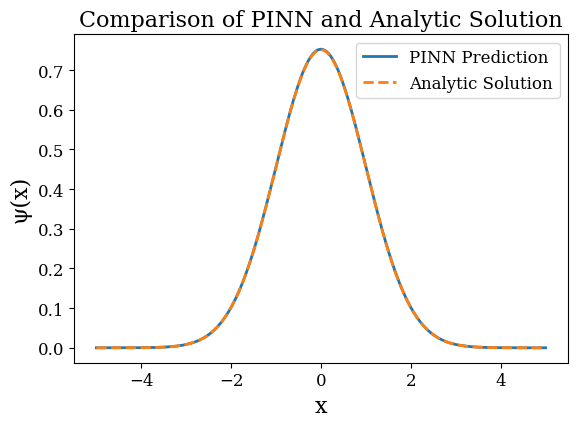

In [8]:
# Load ground state PINN with guessed hyperparameters
pinn1 = load_ground_state_pinn(device)
compare_analytic(x_test, x_lim, pinn1, 0)

As we can see, the model finds the exact ground state solution, even without tuning the hyperparameters. The energy converges to the correct value of $0.5$, and the wavefunction matches the exact solution very well. This makes sense, because the groun state solution is contained within the `ansatzfactor_HO_sym` used, however it is still impressive that the model is able to find the correct energy too.

This model for the ground state is now saved, and will be used to further train for excited states to ensure orthogonality to the ground state.

## First excited state, before grid search 

In this section, we train a neural network to find the first excited state of the quantum harmonic oscillator before any grid search. 

We choose the same values for the hyperparameters as we did for the ground state model, in addition to enforcing orthogonality to the ground state found previously. We set the weight for the orthogonal loss to $1000$, because lower values led to the model collapsing back to the ground state. We also use an initial energy of 0.5 for the excited state, which is what we found from the ground state energy.


In [9]:
ortho_loss_weight = 1000
pinn2 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + ortho_loss_weight*Loss_Orthogonality([pinn1]),
    x_lim=x_lim,
    lr = 5e-2,
    lr_energy=1e-1,
    E_init=0.5,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=7.216e-01. Current loss=7.216e-01. E=1.759272
Epoch 200/3000. Best loss=3.783e-02. Current loss=3.783e-02. E=1.514715
Epoch 300/3000. Best loss=1.244e-02. Current loss=1.898e+00. E=1.489495
Epoch 400/3000. Best loss=1.244e-02. Current loss=6.107e-02. E=1.486236
Epoch 500/3000. Best loss=1.244e-02. Current loss=3.284e-02. E=1.481357
Epoch 600/3000. Best loss=1.244e-02. Current loss=2.486e-02. E=1.473583
Epoch 700/3000. Best loss=1.244e-02. Current loss=2.129e-02. E=1.471069
Epoch 800/3000. Best loss=1.244e-02. Current loss=2.847e-01. E=1.524376
Epoch 900/3000. Best loss=1.244e-02. Current loss=5.206e-02. E=1.465118
Epoch 1000/3000. Best loss=1.244e-02. Current loss=2.663e-02. E=1.414689
Epoch 1100/3000. Best loss=1.244e-02. Current loss=2.075e-02. E=1.397230
Epoch 1200/3000. Best loss=1.244e-02. Current loss=1.474e+00. E=1.460701
Epoch 1300/3000. Best loss=1.244e-02. Current loss=3.441e-02. E=1.354314
Epoch 1400/3000. Best loss=1.244e-02. Current loss=2.707e-02

Predicted Energy: 1.064274, Exact Energy: 1.500000, Relative Error: 29.048403%


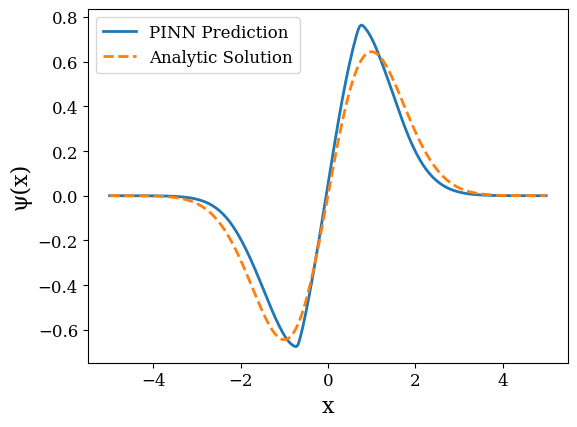

In [10]:
compare_analytic(x_test,x_lim,pinn2, n=1, show=False, title=False)
plt.savefig("../figs/pre_search_pinn1.pdf")
plt.show()

We see that the neural network ends up with a solution with a similar shape to the first excited energy level. However, it is nonehtless slightly off. The energy ends up being about 1.10, corresponding to a relative error of about 26.6%.